# **SARIMA & SARIMAX**

## **IMPORTS**

In [2]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

## **DATASET LOADING**

In [3]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Check all variables
X = df_original.drop(["cnt", "casual", "registered", "instant", "dteday", "atemp", "hr", "season", "weekday"], axis="columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [4]:
# 1. Define where we make the cut (Cut-off point). 
# For example, use 80% of historical data for training and save 20% final for testing.
split_index = int(len(df_original) * 0.80)

# 2. Split exogenous variables matrix (X)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Split target variables (y) - Casual Users
y_casual_train = y_casual.iloc[:split_index]
y_casual_test = y_casual.iloc[split_index:]

# 4. Split target variables (y) - Registered Users
y_registered_train = y_registered.iloc[:split_index]
y_registered_test = y_registered.iloc[split_index:]

print(f"Training size: {len(y_casual_train)} hours")
print(f"Test size: {len(y_casual_test)} hours")

Training size: 13903 hours
Test size: 3476 hours


## **SARIMA**

We are looking for: (p, d, q) * (P, D, Q, s)

We already know that s = 24, as the main seasonality is hourly (we know this due to the analysis we made in deliverable 1)

### Check Stationary (ADF test) --> d

In [10]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [11]:
print("ADF CASUAL TEST..............")
adf_test(y_casual_train)

print("\nADF CASUAL TEST..............")
adf_test(y_registered_train)

#both stationary

ADF CASUAL TEST..............
ADF Statistic: -12.349734854771963
p-value: 5.862140334336988e-23
(np.float64(-12.349734854771963), np.float64(5.862140334336988e-23), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(112087.83190065622))

ADF CASUAL TEST..............
ADF Statistic: -7.4455733965650674
p-value: 5.850617439283626e-11
(np.float64(-7.4455733965650674), np.float64(5.850617439283626e-11), 42, 13860, {'1%': np.float64(-3.4308218983783987), '5%': np.float64(-2.8617485574092236), '10%': np.float64(-2.5668810102936184)}, np.float64(147261.09601416928))


This means that we already have the d parameter for both time series, d = 0

### Seasonal Difference (ACF Plots) --> D

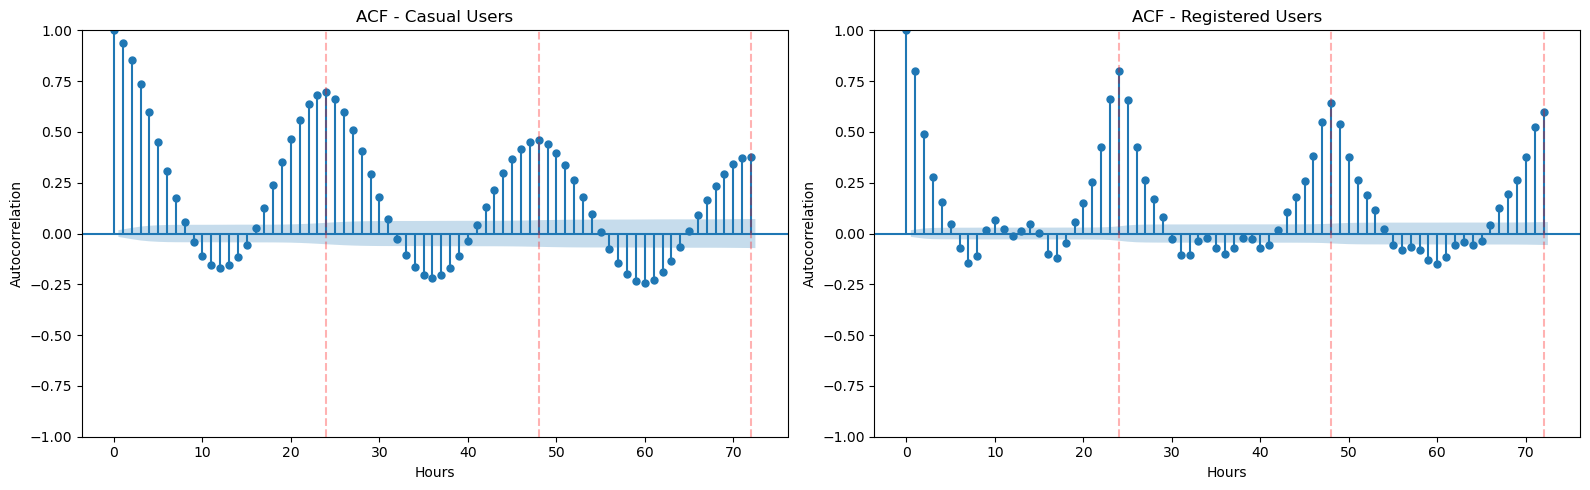

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima.arima.utils import nsdiffs

# 1 line, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Casual users (lags=72 to check 3 days)
plot_acf(y_casual_train, lags=72, ax=axes[0], title='ACF - Casual Users')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')

# Add lines every 24 hours, which is our s
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.3)

# Same for registered users
plot_acf(y_registered_train, lags=72, ax=axes[1], title='ACF - Registered Users')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

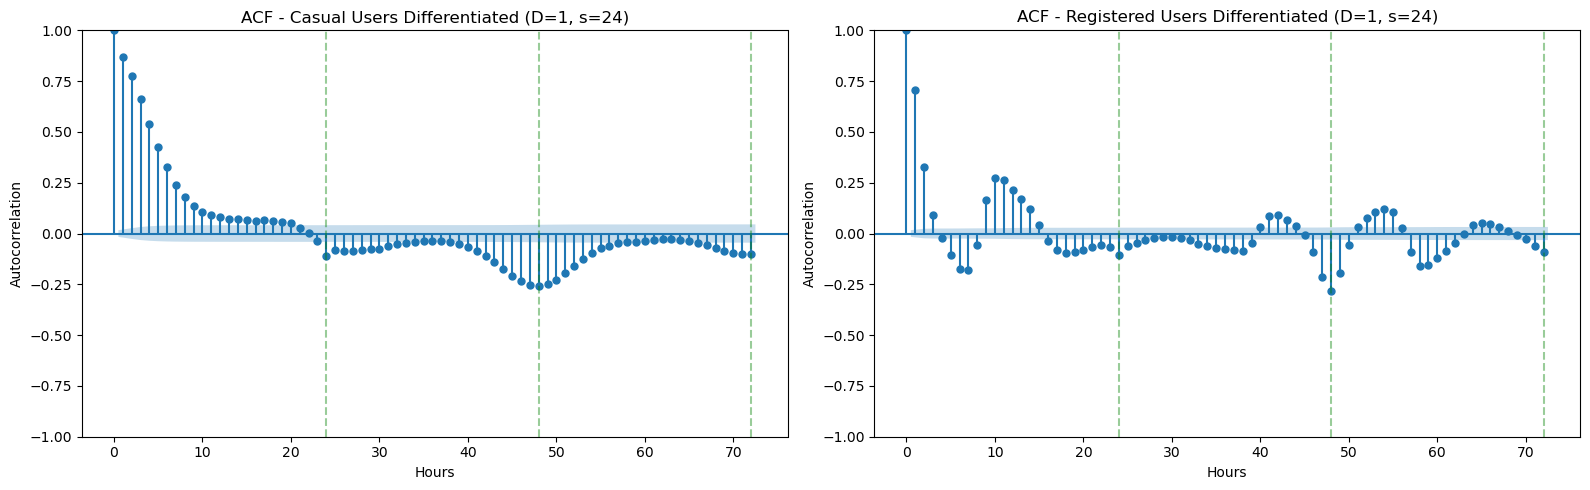

In [13]:
# Subtract from each value, the value from 24 hours ago
y_casual_diff = y_casual_train.diff(periods=24).dropna()
y_registered_diff = y_registered_train.diff(periods=24).dropna()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_casual_diff, lags=72, ax=axes[0], title='ACF - Casual Users Differentiated (D=1, s=24)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='green', linestyle='--', alpha=0.4) # Changed to green to differentiate it

plot_acf(y_registered_diff, lags=72, ax=axes[1], title='ACF - Registered Users Differentiated (D=1, s=24)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='green', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

This means that we already have the D parameter for both time series, D = 1

### Applying AIC (Grid Search) --> p,q,P,Q

In [5]:
import pandas as pd
from typing import Union
from itertools import product
from tqdm.notebook import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from joblib import Parallel, delayed # NEW: Multiprocessing library

# Ignore convergence warnings
warnings.filterwarnings("ignore")

# NEW: Helper function. Joblib needs us to isolate the work of a single model.
def _fit_single_model(order, endog, d, D, s):
    try:
        model = SARIMAX(
            endog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False,
            # Small extra trick so it doesn't get stuck looking for mathematical perfection:
            enforce_stationarity=False, 
            enforce_invertibility=False
        ).fit(disp=False)
        return [order, model.aic]
    except Exception:
        # If it fails, returns None so we ignore it later
        return None

def optimize_SARIMA_fast(endog: pd.Series, order_list: list, d: int, D: int, s: int, n_jobs: int = -1) -> pd.DataFrame:
    """
    Optimizes SARIMA using multiprocessing.
    n_jobs = -1 means "Use absolutely all available CPU cores".
    """
    print(f"Launching {len(order_list)} models in parallel...")
    
    # NEW: Parallelization magic. This launches the models simultaneously.
    # We use tqdm to keep the progress bar alive
    results = list(tqdm(
    Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(_fit_single_model)(order, endog, d, D, s) 
        for order in order_list
    ),
    total=len(order_list),
    desc="Evaluating combinations"
))

    # Clean up models that failed (those that returned None)
    valid_results = [r for r in results if r is not None]

    result_df = pd.DataFrame(valid_results, columns=['(p,q,P,Q)', 'AIC'])
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

#### *Casual*

In [10]:
# We maintain the ranges [0, 1, 2] which give 81 combinations
ps = range(0, 3, 1) 
qs = range(0, 3, 1) 
Ps = range(0, 3, 1) 
Qs = range(0, 3, 1) 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d_val = 0
D_val = 1
s_val = 24

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_casual_subset = y_casual_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for CASUAL users...")
# Call the new parallelized function
result_casual_fast = optimize_SARIMA_fast(y_casual_subset, SARIMA_order_list, d_val, D_val, s_val, n_jobs=8)

display(result_casual_fast.head())

Starting ULTRA FAST Grid Search for CASUAL users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 1, 2)",12204.827130
1,"(2, 2, 2, 2)",12206.781352
2,"(2, 2, 0, 2)",12207.897005
3,"(1, 2, 1, 2)",12211.620189
4,"(1, 2, 2, 2)",12213.550432


#### *Registered*

In [11]:
# Now for the registered users

# THE DATA TRICK: We take only the last 1500 rows of training
# This represents approximately the last 60 days of history.
y_registered_subset = y_registered_train.iloc[-1500:]

print("Starting ULTRA FAST Grid Search for REGISTERED users...")
# Call the new parallelized function
result_registered_fast = optimize_SARIMA_fast(y_registered_subset, SARIMA_order_list, d_val, D_val, s_val)

display(result_registered_fast.head())

Starting ULTRA FAST Grid Search for REGISTERED users...
Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 2, 2)",15612.939322
1,"(1, 2, 2, 2)",15625.317343
2,"(2, 0, 2, 2)",15626.973385
3,"(2, 1, 2, 2)",15628.775844
4,"(0, 2, 2, 2)",15648.416415


### Residual analysis

#### *Casual*

Training final CASUAL model with: (p=2, d=0, q=2) x (P=1, D=1, Q=2, s=24)


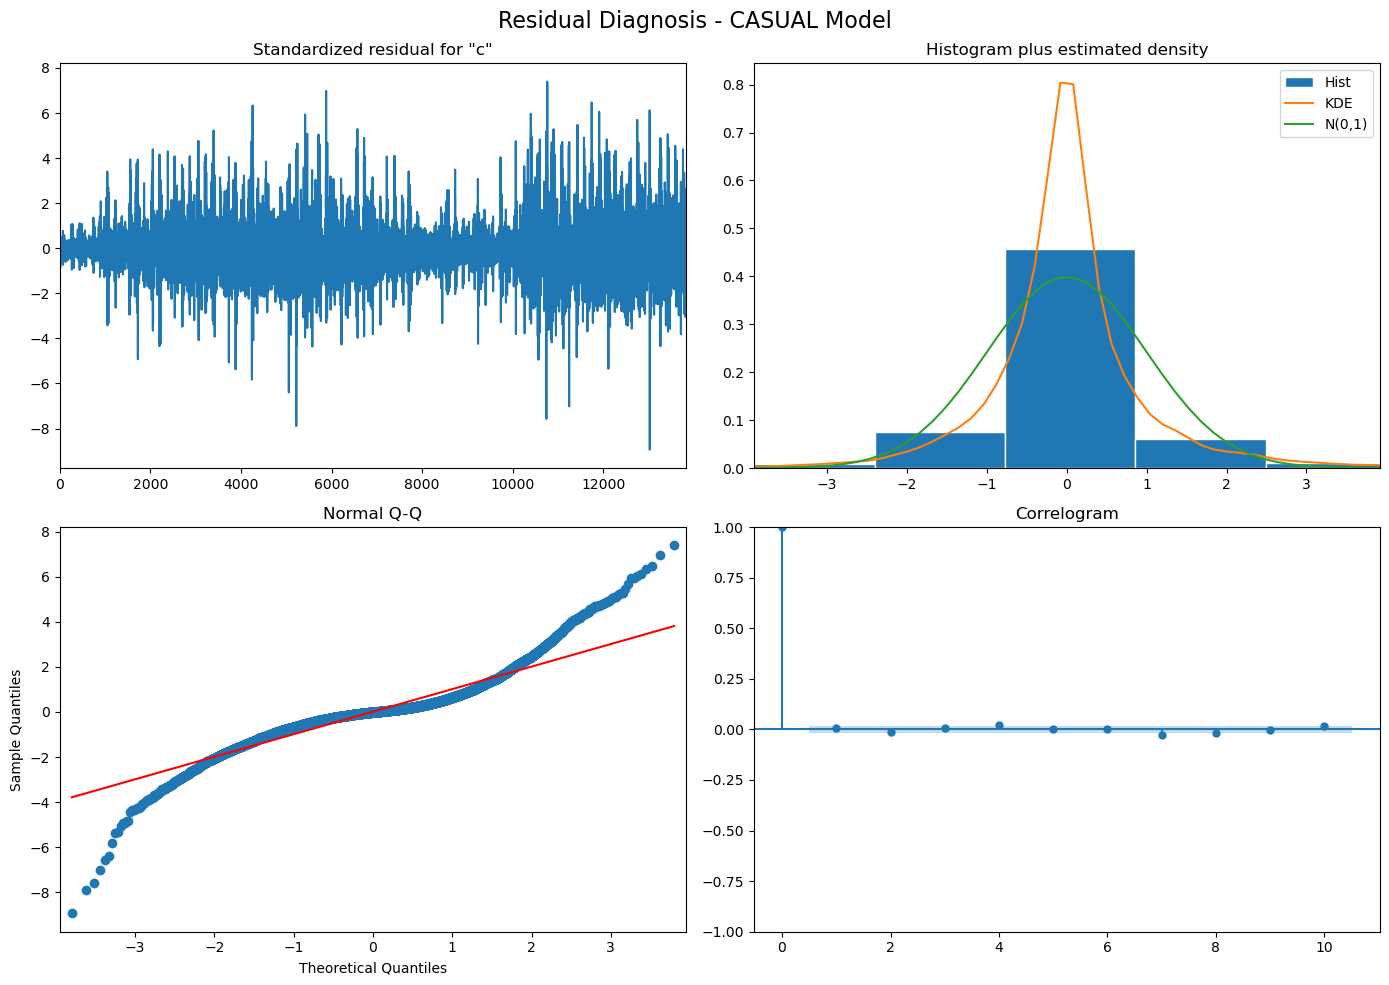


--- Ljung-Box Test (Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,42.470137,2.775173e-05
24,390.536881,6.558925e-68


In [13]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
import os
os.environ["OMP_NUM_THREADS"] = "14"
os.environ["OPENBLAS_NUM_THREADS"] = "14"
os.environ["MKL_NUM_THREADS"] = "14"

# 1. Retrieve the best parameters from the Grid Search for casual users
# Replace these variables with the actual numbers that won in the table!
best_p_casual, best_q_casual = 2, 2 
best_P_casual, best_Q_casual = 1, 2 

print(f"Training final CASUAL model with: (p={best_p_casual}, d=0, q={best_q_casual}) x (P={best_P_casual}, D=1, Q={best_Q_casual}, s=24)")

# 2. Train the final model
model_casual_final = SARIMAX(
    y_casual_train, 
    order=(best_p_casual, 0, best_q_casual), 
    seasonal_order=(best_P_casual, 1, best_Q_casual, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
fit_casual_final = model_casual_final.fit(disp=True)

# 3. Qualitative Diagnosis (The 4 plots)
fig = fit_casual_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - CASUAL Model', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_casual = fit_casual_final.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_casual = acorr_ljungbox(residuals_casual.dropna(), lags=[12, 24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_casual)

#### *Registered*

Training final REGISTERED model with: (p=2, d=0, q=2) x (P=2, D=1, Q=2, s=24)


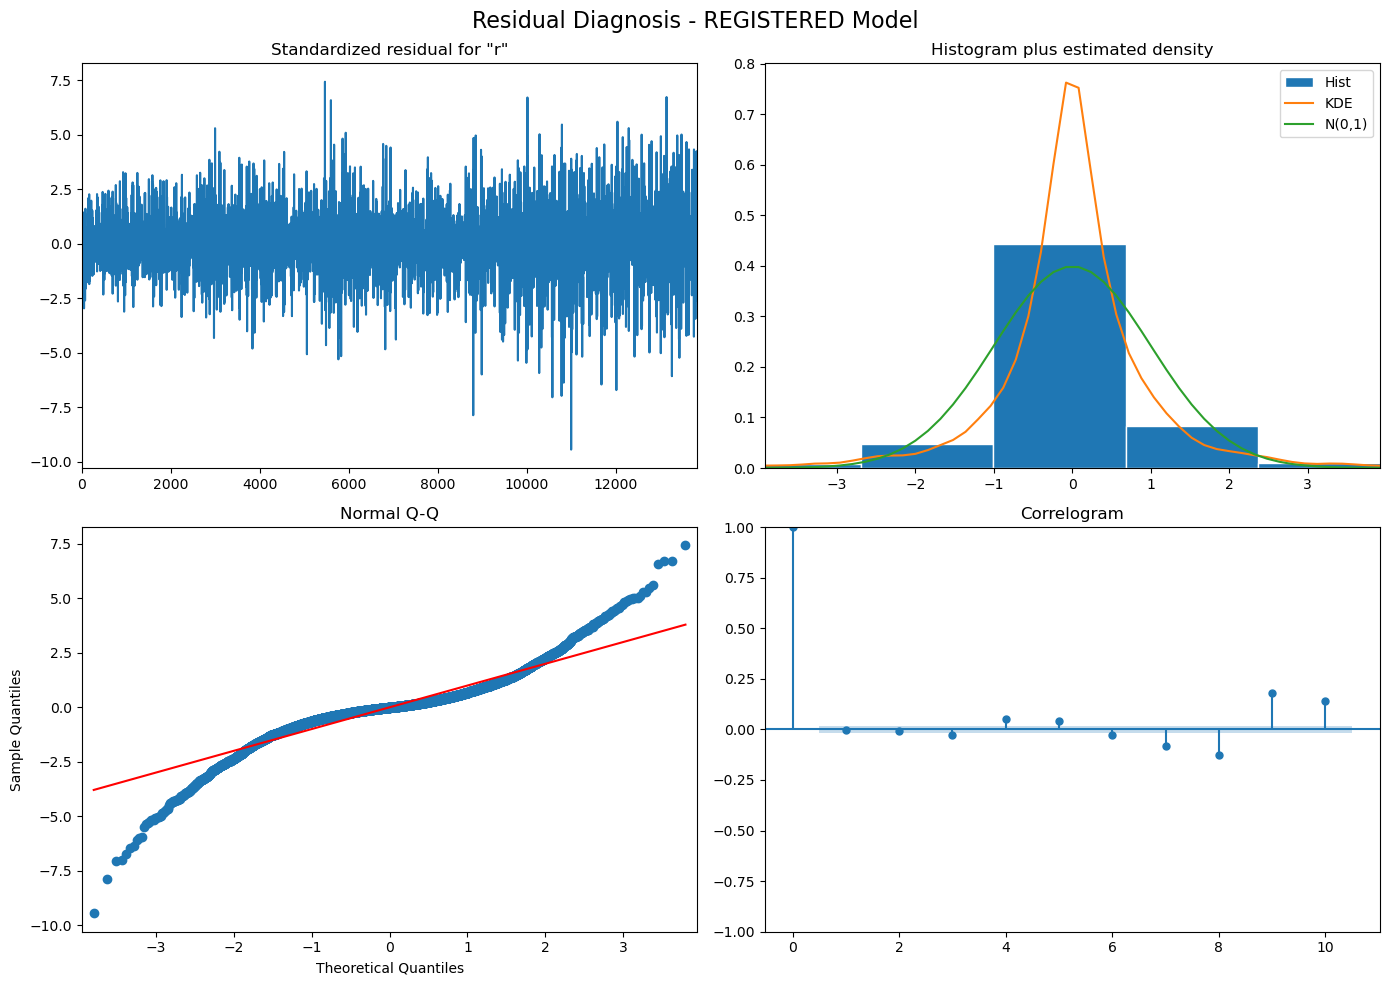


--- Ljung-Box Test (Registered) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
12,1157.265343,2.751819e-240
24,1382.426248,2.828051e-277


In [14]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Retrieve the best parameters from the Grid Search for casual users
# Replace these variables with the actual numbers that won in the table!
best_p_registered, best_q_registered = 2, 2 
best_P_registered, best_Q_registered = 2, 2 

print(f"Training final REGISTERED model with: (p={best_p_registered}, d=0, q={best_q_registered}) x (P={best_P_registered}, D=1, Q={best_Q_registered}, s=24)")

# 2. Train the final model
model_registered_final = SARIMAX(
    y_registered_train, 
    order=(best_p_registered, 0, best_q_registered), 
    seasonal_order=(best_P_registered, 1, best_Q_registered, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)
fit_registered_final = model_registered_final.fit(disp=False)

# 3. Qualitative Diagnosis (The 4 plots)
fig = fit_registered_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - REGISTERED Model', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_registered = fit_registered_final.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_registered = acorr_ljungbox(residuals_registered.dropna(), lags=[12, 24])
print("\n--- Ljung-Box Test (Registered) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_registered)

### Results

#### *Casual*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from tqdm.notebook import tqdm

# =====================================================================
# 1. GET PREDICTIONS (WALK-FORWARD VALIDATION - 24H)
# =====================================================================
print("Starting Walk-Forward simulation (Prediction 24 by 24 hours)...")

predictions = []
# We clone the state of the trained model to keep updating it
current_res = fit_casual_final 
step_size = 24
test_length = len(y_casual_test)

for i in tqdm(range(0, test_length, step_size), desc="Simulated days"):
    print(f"prediction {i} out of {test_length // step_size}")
    # 1. Predict the next 24 hours
    # If we are at the end and less than 24h remain, we predict only what remains
    current_step = min(step_size, test_length - i)
    pred = current_res.forecast(steps=current_step)
    
    # We save these 24 hours of prediction in our general list
    predictions.extend(pred)
    
    # 2. We discover the reality: we extract the 24 real hours from the Test Set
    actual_data_chunk = y_casual_test.iloc[i : i + current_step]
    
    # 3. UPDATE (The magic of Walk-Forward)
    # We inject the real data into the model so it assimilates them as "past"
    # refit=False ensures it doesn't retrain the parameters, only updates the memory
    current_res = current_res.append(actual_data_chunk, refit=False)

# We convert the prediction list into a Pandas Series with the correct index
casual_pred_series = pd.Series(predictions, index=y_casual_test.index)

# =====================================================================
# 2. ERROR METRICS (Quantitative)
# =====================================================================
mape_casual = mean_absolute_percentage_error(y_casual_test, casual_pred_series)
print(f"\n--- SARIMA Walk-Forward Evaluation (Casual) ---")
print(f"MAPE (Mean Absolute Percentage Error at 24h view): {mape_casual * 100:.2f}%")

# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Context: Last week of Train
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')

# Reality: The Test Set
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')

# Prediction: Our series built block by block of 24h
ax.plot(y_casual_test.index, casual_pred_series, label='SARIMA Walk-Forward (24h)', color='green', linestyle='--')

# Shading of the Test Set
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Walk-Forward Prediction (24h) vs Reality - Casual Users', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Casual Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: We maintain the limit to see the detail of daily cuts
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 

plt.tight_layout()
plt.show()

#### *Registered*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from tqdm.notebook import tqdm

# =====================================================================
# 1. GET PREDICTIONS (WALK-FORWARD VALIDATION - 24H)
# =====================================================================
print("Starting Walk-Forward simulation (Prediction 24 by 24 hours)...")

predictions = []
# We clone the state of the trained model to keep updating it
current_res = fit_casual_final 
step_size = 24
test_length = len(y_casual_test)

for i in tqdm(range(0, test_length, step_size), desc="Simulated days"):
    print(f"prediction {i} out of {test_length // step_size}")
    # 1. Predict the next 24 hours
    # If we are at the end and less than 24h remain, we predict only what remains
    current_step = min(step_size, test_length - i)
    pred = current_res.forecast(steps=current_step)
    
    # We save these 24 hours of prediction in our general list
    predictions.extend(pred)
    
    # 2. We discover the reality: we extract the 24 real hours from the Test Set
    actual_data_chunk = y_casual_test.iloc[i : i + current_step]
    
    # 3. UPDATE (The magic of Walk-Forward)
    # We inject the real data into the model so it assimilates them as "past"
    # refit=False ensures it doesn't retrain the parameters, only updates the memory
    current_res = current_res.append(actual_data_chunk, refit=False)

# We convert the prediction list into a Pandas Series with the correct index
casual_pred_series = pd.Series(predictions, index=y_casual_test.index)

# =====================================================================
# 2. ERROR METRICS (Quantitative)
# =====================================================================
mape_casual = mean_absolute_percentage_error(y_casual_test, casual_pred_series)
print(f"\n--- SARIMA Walk-Forward Evaluation (Casual) ---")
print(f"MAPE (Mean Absolute Percentage Error at 24h view): {mape_casual * 100:.2f}%")

# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Context: Last week of Train
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')

# Reality: The Test Set
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')

# Prediction: Our series built block by block of 24h
ax.plot(y_casual_test.index, casual_pred_series, label='SARIMA Walk-Forward (24h)', color='green', linestyle='--')

# Shading of the Test Set
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Walk-Forward Prediction (24h) vs Reality - Casual Users', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Number of Casual Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: We maintain the limit to see the detail of daily cuts
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 

plt.tight_layout()
plt.show()

## **SARIMAX**

We are looking for: (p, d, q) * (P, D, Q, s) + we add exogenous variables 

We already have the results of the SARIMA model, so we will use them. Even though SARIMAX adds exogenous variables, the basis of the model is the same. We could consider doing an extensive search again (as grid search), but taking into account the time we needed to execute the previous one, and that now we are adding a huge matrix with all the exogenous variables (which would make things a lot slower), we will use the already calculated values.

* Casual Users:
    * p, d, q = 2, 0, 2
    * P, D, Q = 1, 1, 2
    * s = 24

* Registered Users:
    * p, d, q = 2, 0, 2
    * P, D, Q = 2, 1, 2
    * s = 24

### Training

#### *Casual*

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

import os
os.environ["OMP_NUM_THREADS"] = "14"
os.environ["OPENBLAS_NUM_THREADS"] = "14"
os.environ["MKL_NUM_THREADS"] = "14"

# We reuse the winning hyperparameters from your fast Grid Search
best_p_casual, best_q_casual = 2, 2 # Replace with your real ones
best_P_casual, best_Q_casual = 1, 2 # Replace with your real ones

print("Training FINAL SARIMAX model (Casual) with exogenous variables...")

# The big difference: We add exog=X_train
model_sarimax_casual = SARIMAX(
    endog=y_casual_train, 
    exog=X_train,  # <--- EXOGENOUS MATRIX HERE
    order=(best_p_casual, 0, best_q_casual), 
    seasonal_order=(best_P_casual, 1, best_Q_casual, 24), 
    simple_differencing=False,
    enforce_stationarity=False, 
    enforce_invertibility=False
)

# We train
fit_sarimax_casual = model_sarimax_casual.fit(disp=True)
print("Training completed.")

Training FINAL SARIMAX model (Casual) with exogenous variables...
Optimization terminated successfully.
         Current function value: 4.019845
         Iterations: 4
         Function evaluations: 622
Training completed.


### Residual analysis

#### *Casual*

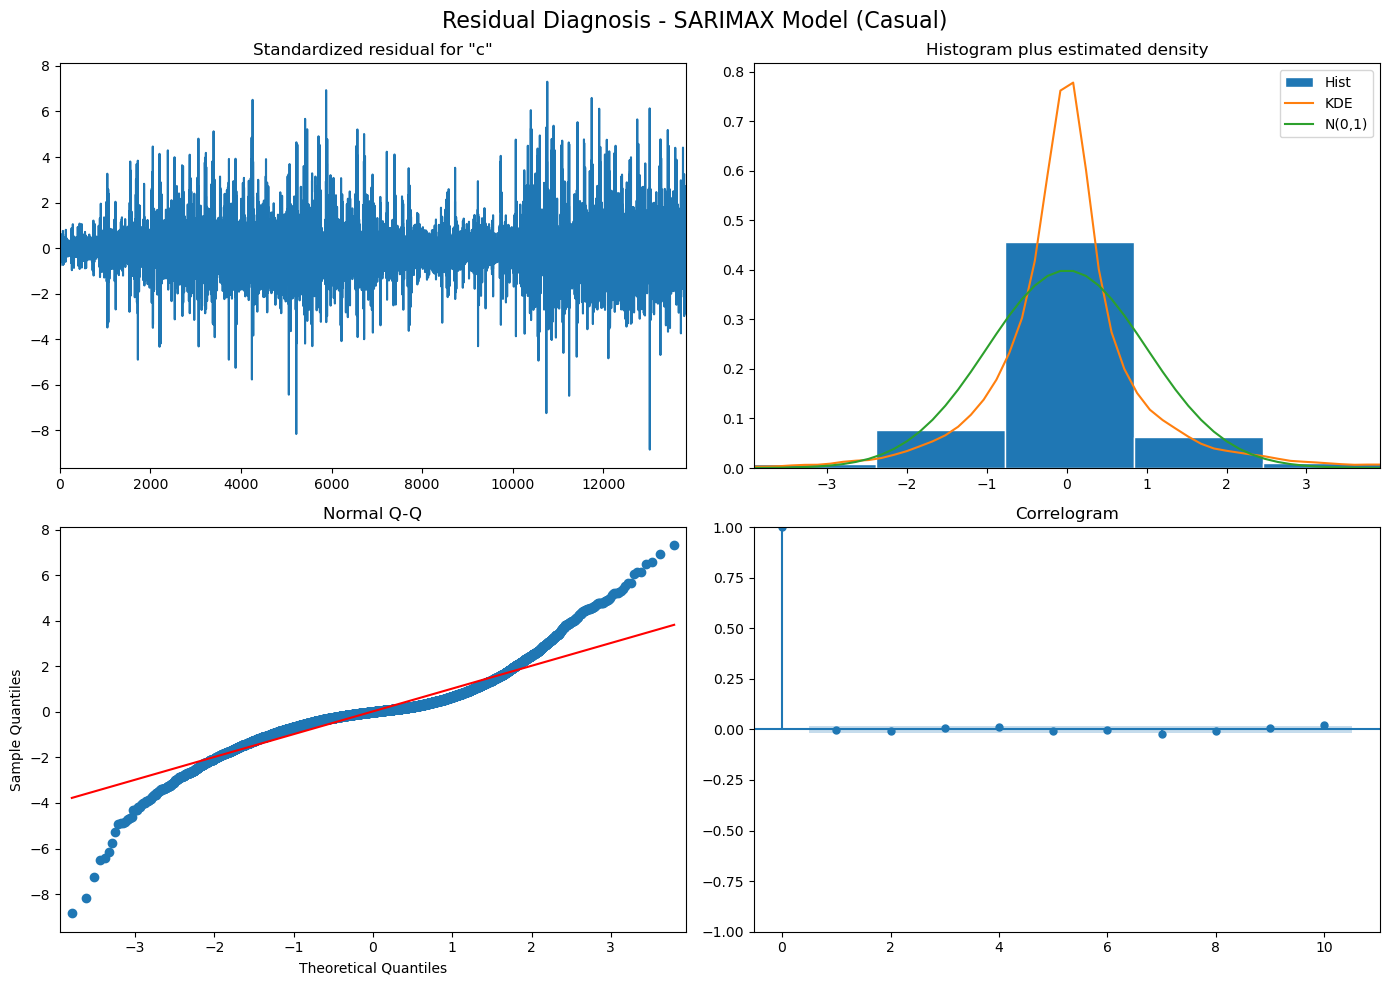


--- Ljung-Box Test (SARIMAX Casual) ---


,lb_stat,lb_pvalue
12,64.01383,4.146112e-09
24,415.35690,5.248772e-73


In [9]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Qualitative plots
fig = fit_sarimax_casual.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - SARIMAX Model (Casual)', fontsize=16)
plt.tight_layout()
plt.show()

# Quantitative Test (Ljung-Box)
residuals_sarimax = fit_sarimax_casual.resid
lb_test_sarimax = acorr_ljungbox(residuals_sarimax.dropna(), lags=[12, 24])

print("\n--- Ljung-Box Test (SARIMAX Casual) ---")
display(lb_test_sarimax)

### Retrain

#### *Casual*

In [6]:
# We maintain the ranges [0, 1, 2] which give 81 combinations
ps = range(0, 3, 1) 
qs = range(0, 3, 1) 
Ps = range(0, 3, 1) 
Qs = range(0, 3, 1) 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))

d_val = 0
D_val = 1
s_val = 24

# 1. Creamos el subset logarítmico (1500 filas)
y_subset_log = np.log1p(y_casual_train.iloc[-1500:])

# 2. Buscamos los parámetros (¡SIN matriz X!)
resultados_log = optimize_SARIMA_fast(
    endog=y_subset_log, 
    order_list=SARIMA_order_list, 
    d=d_val, 
    D=D_val, 
    s=s_val, 
)
# Apuntas los parámetros ganadores que salgan el top 1

display(resultados_log.head())

Launching 81 models in parallel...


Evaluating combinations:   0%|          | 0/81 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(1, 2, 0, 2)",1778.399692
1,"(1, 2, 1, 2)",1780.356268
2,"(2, 2, 0, 2)",1780.398108
3,"(2, 2, 1, 2)",1782.353677
4,"(1, 2, 2, 2)",1782.392157


In [7]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

import os
os.environ["OMP_NUM_THREADS"] = "14"
os.environ["OPENBLAS_NUM_THREADS"] = "14"
os.environ["MKL_NUM_THREADS"] = "14"

# We reuse the winning hyperparameters from your fast Grid Search
best_p_log, best_q_log = 1, 2 # Replace with your real ones
best_P_log, best_Q_log = 0, 2 # Replace with your real ones

# Convertimos TODO el train a logaritmo
y_casual_train_log = np.log1p(y_casual_train)

# Creamos el SARIMAX definitivo
model_sarimax_log = SARIMAX(
    endog=y_casual_train_log, 
    exog=X_train,  # <--- AQUÍ entra el clima
    order=(best_p_log, 0, best_q_log), 
    seasonal_order=(best_P_log, 1, best_Q_log, 24), 
    simple_differencing=False
)
fit_sarimax_log = model_sarimax_log.fit(disp=False)

print("Training completed.")

Training completed.


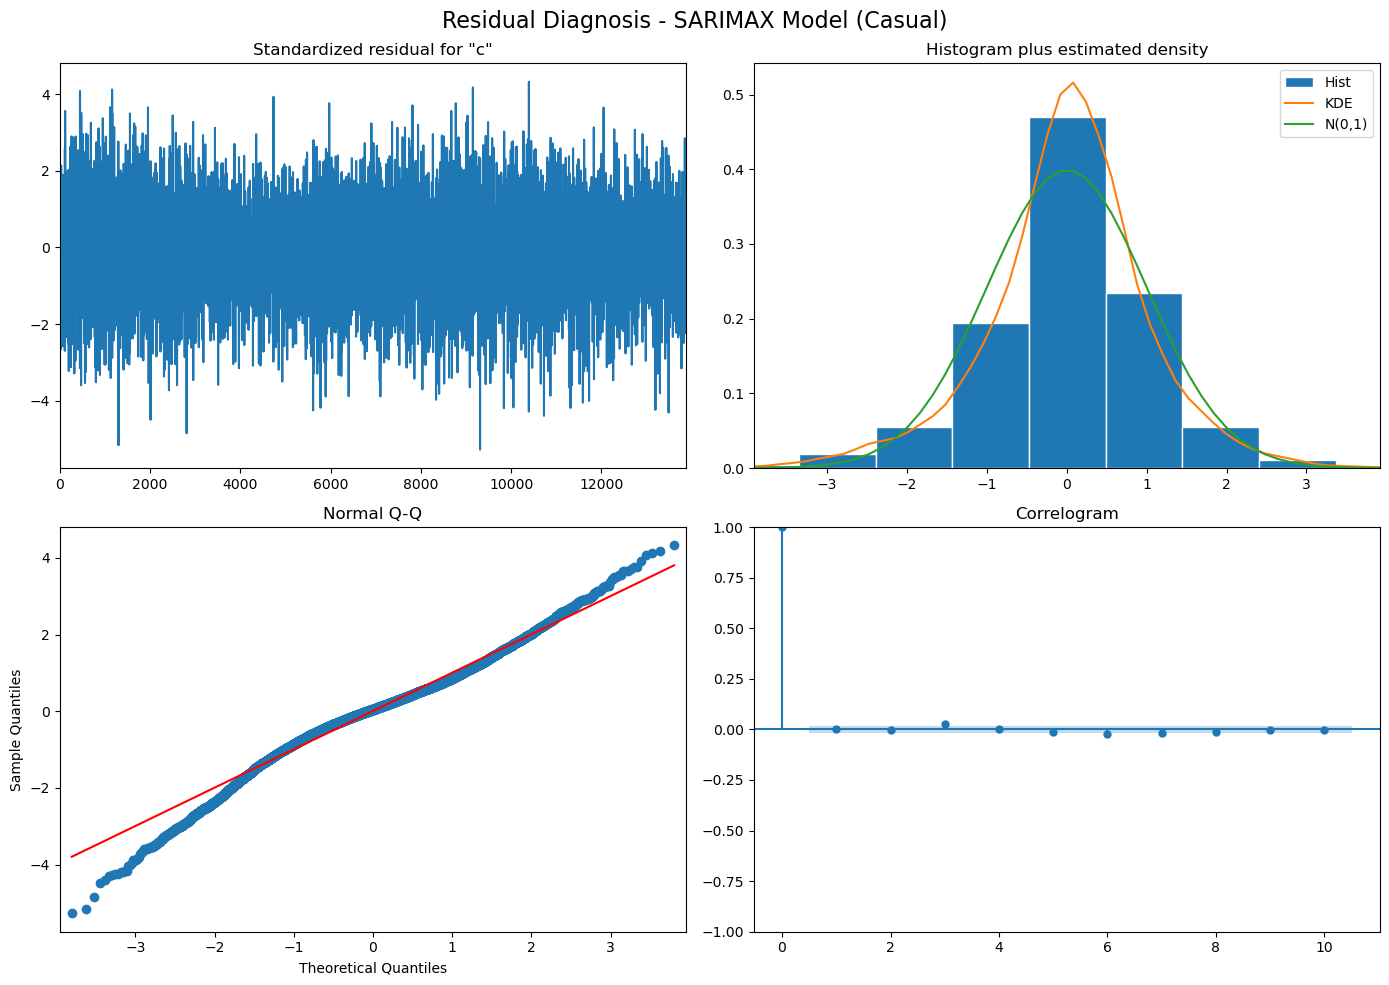


--- Ljung-Box Test (SARIMAX Casual) ---


,lb_stat,lb_pvalue
12,56.822535,8.509160e-08
24,441.332060,2.333432e-78


In [9]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Qualitative plots
fig = fit_sarimax_log.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Residual Diagnosis - SARIMAX Model (Casual)', fontsize=16)
plt.tight_layout()
plt.show()

# Quantitative Test (Ljung-Box)
residuals_sarimax = fit_sarimax_log.resid
lb_test_sarimax = acorr_ljungbox(residuals_sarimax.dropna(), lags=[12, 24])

print("\n--- Ljung-Box Test (SARIMAX Casual) ---")
display(lb_test_sarimax)

### Results

#### *Casual*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
from tqdm.notebook import tqdm

print("Starting Walk-Forward simulation (SARIMAX LOG - 24h)...")

predictions_sarimax_real = []
current_res_sarimax = fit_sarimax_casual # Asumiendo que este modelo se entrenó con np.log1p(y_train)
step_size = 24
test_length = len(y_casual_test)

for i in tqdm(range(0, test_length, step_size), desc="Simulated days"):
    print(f"Step {i} out of {test_length // step_size}")
    current_step = min(step_size, test_length - i)
    
    # 1. We extract the FUTURE WEATHER (X_test) for these 24 hours
    exog_future_chunk = X_test.iloc[i : i + current_step]
    
    # 2. PREDICT (Returns Logarithmic values)
    pred_log = current_res_sarimax.forecast(steps=current_step, exog=exog_future_chunk)
    
    # TRUCO MATEMÁTICO: Deshacemos el logaritmo para tener BICICLETAS REALES
    pred_real = np.expm1(pred_log)
    predictions_sarimax_real.extend(pred_real)
    
    # 3. We discover the REALITY of rentals (y_test) in REAL bicycles
    actual_y_chunk_real = y_casual_test.iloc[i : i + current_step]
    
    # TRUCO MATEMÁTICO: Convertimos la realidad a logaritmo para que el modelo la entienda
    actual_y_chunk_log = np.log1p(actual_y_chunk_real)
    
    # 4. MEMORY UPDATE
    # Le pasamos la realidad en LOGARITMO y el clima
    current_res_sarimax = current_res_sarimax.append(
        endog=actual_y_chunk_log, 
        exog=exog_future_chunk, 
        refit=False
    )

# Format results
casual_pred_sarimax_series = pd.Series(predictions_sarimax_real, index=y_casual_test.index)

# Calculate final error (Comparing REAL bicycles vs REAL predictions)
mape_sarimax = mean_absolute_percentage_error(y_casual_test, casual_pred_sarimax_series)
print(f"\n--- Final SARIMAX (Log-Transformed) Walk-Forward Evaluation (Casual) ---")
print(f"MAPE (Error at 24h view with weather): {mape_sarimax * 100:.2f}%")

# Draw the ZOOM chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')
ax.plot(y_casual_test.index, casual_pred_sarimax_series, label='SARIMAX Prediction (24h)', color='green', linestyle='--')
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)
ax.set_title('SARIMAX Prediction vs Reality (With exogenous variables & Log correction)', fontsize=16)
ax.set_xlabel('Time Index')
ax.set_ylabel('Casual Rentals')
ax.legend(loc='upper left')
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 
plt.tight_layout()
plt.show()